<a href="https://colab.research.google.com/github/Hiroj12b/Cn6005/blob/main/Part1_Preprocessing_and_LogReg_Hiroj_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.datasets import fashion_mnist


In [2]:
# Step 1: Load the FashionMNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set shape: (60000, 28, 28) (60000,)
Test set shape: (10000, 28, 28) (10000,)


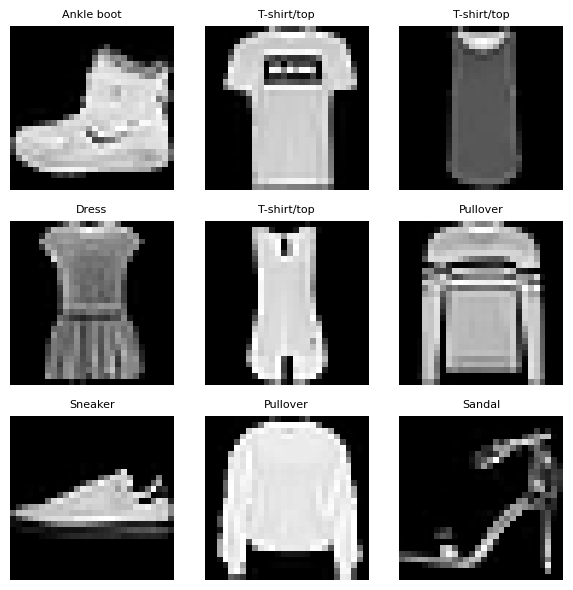

In [3]:
# Class names for readability
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Step 2: Visualise some sample images
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


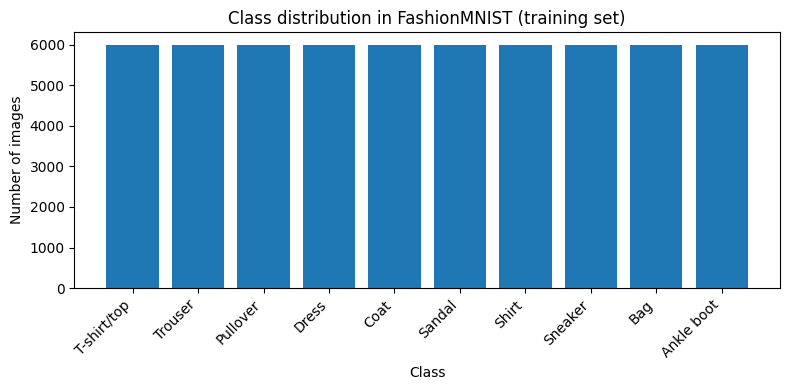

In [4]:
# Step 3: Check class distribution
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(unique, counts)
plt.xticks(unique, class_names, rotation=45, ha="right")
plt.title("Class distribution in FashionMNIST (training set)")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()


In [5]:
# Step 4: Normalise pixel values to [0, 1]
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

# Flatten 28x28 images into 784-length vectors
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat  = X_test_norm.reshape(X_test_norm.shape[0], -1)

print("Flattened training shape:", X_train_flat.shape)
print("Flattened test shape:    ", X_test_flat.shape)


Flattened training shape: (60000, 784)
Flattened test shape:     (10000, 784)


In [6]:
# Step 5: Use a subset of the training data for faster training
n_samples = 10000  # you can change to 15000 or 20000 if your laptop is okay

X_train_sub = X_train_flat[:n_samples]
y_train_sub = y_train[:n_samples]

print("Subset shape:", X_train_sub.shape, y_train_sub.shape)


Subset shape: (10000, 784) (10000,)


In [7]:
# Step 6: Define and train the Logistic Regression model
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=200,
    n_jobs=-1
)

log_reg.fit(X_train_sub, y_train_sub)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='multinomial', n_jobs=-1,
                   solver='saga')

In [8]:
# Step 7: Evaluate the model on the test set
y_pred = log_reg.predict(X_test_flat)

# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))


Test Accuracy: 0.8291

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.78      0.79      1000
     Trouser       0.97      0.96      0.96      1000
    Pullover       0.69      0.72      0.71      1000
       Dress       0.83      0.83      0.83      1000
        Coat       0.72      0.75      0.73      1000
      Sandal       0.94      0.89      0.91      1000
       Shirt       0.59      0.56      0.57      1000
     Sneaker       0.90      0.94      0.92      1000
         Bag       0.93      0.92      0.93      1000
  Ankle boot       0.93      0.94      0.93      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



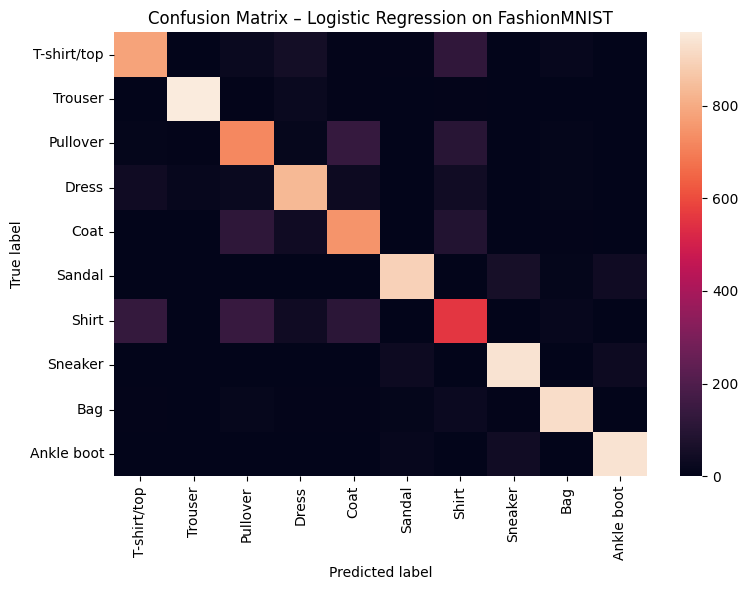

In [9]:
# Step 8: Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=False,    # set True if you want numbers, but it can get crowded
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Logistic Regression on FashionMNIST")
plt.tight_layout()
plt.show()


In [10]:
# ===== Step 1: Load dataset =====
# ===== Step 2: Visualise sample images =====
# ===== Step 3: Data preprocessing =====
# ===== Step 4: Train Logistic Regression =====
# ===== Step 5: Evaluate model =====
